In [194]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import scipy
from scipy import stats
from statsmodels.stats.power import TTestIndPower, zt_ind_solve_power
from statsmodels.stats.weightstats import ztest, zconfint
from statsmodels.stats.proportion import proportion_confint
import seaborn as sns

In [248]:
pd.__version__

'1.5.3'

In [249]:
np.__version__

'1.23.5'

In [253]:
import matplotlib
matplotlib.__version__

'3.7.0'

In [254]:
scipy.__version__

'1.10.0'

In [255]:
import statsmodels
statsmodels.__version__

'0.13.5'

In [256]:
sns.__version__

'0.12.2'

In [209]:
days = 100

In [210]:
mu_control, sigma_control, n_control = 100, 20, 100
mu_experiment, sigma_experiment, n_experiment = 100, 20, 100

In [211]:
current_date = 1
user_data = pd.DataFrame()
stat_result = pd.DataFrame()
daily_data = pd.DataFrame()

In [212]:
for day in range(days):
    daily_data_control = np.random.normal(mu_control, sigma_control, n_control)
    daily_data_experiment = np.random.normal(mu_experiment, sigma_experiment, n_experiment)
    
    day_data_control = pd.DataFrame({'value': daily_data_control})
    day_data_control['date'] = current_date
    day_data_control['group'] = 'control'

    
    day_data_experiment = pd.DataFrame({'value': daily_data_experiment})
    day_data_experiment['date'] = current_date
    day_data_experiment['group'] = 'experiment'

    
    user_data = user_data.append(day_data_experiment).append(day_data_control)
    fit = stats.ttest_ind(user_data[user_data.group == 'experiment'].value, 
                          user_data[user_data.group == 'control'].value)

    
    stat_result = stat_result.append(pd.DataFrame({'t': [fit[0]], 'p': [fit[1]], 'date': current_date}))
    
    
    current_data_stat = user_data.groupby(['group'], as_index=False).agg({'value': 'mean'})
    current_data_stat['date'] = current_date
    
    daily_data = daily_data.append(current_data_stat)
    
    current_date += 1


/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  user_data = user_data.append(day_data_experiment).append(day_data_control)
/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:20: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  stat_result = stat_result.append(pd.DataFrame({'t': [fit[0]], 'p': [fit[1]], 'date': current_date}))
/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  daily_data = daily_data.append(current_data_stat)
/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:15: FutureWarning: The frame.append method is

/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:15: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  user_data = user_data.append(day_data_experiment).append(day_data_control)
/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:20: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  stat_result = stat_result.append(pd.DataFrame({'t': [fit[0]], 'p': [fit[1]], 'date': current_date}))
/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:26: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  daily_data = daily_data.append(current_data_stat)
/var/folders/cg/z1gdqpsx1qq3lyb5lp3896zh0000gq/T/ipykernel_90502/228655152.py:15: FutureWarning: The frame.append method is

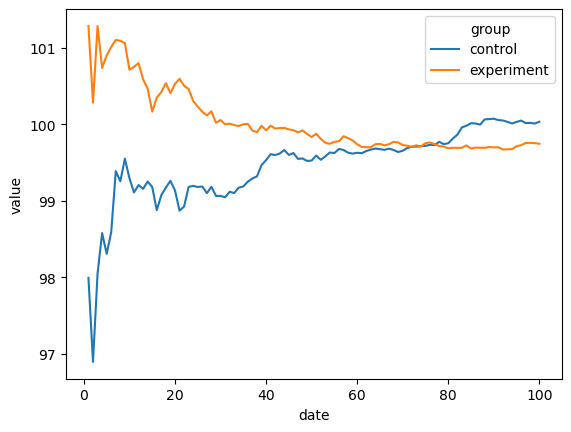

In [213]:
ax = sns.lineplot(data=daily_data, x="date", y="value", hue='group')

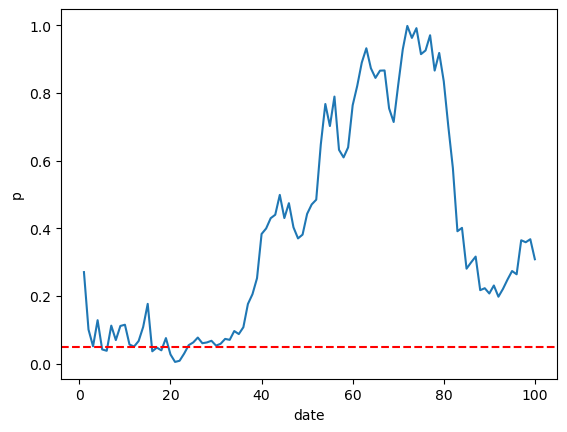

In [214]:
ax = sns.lineplot(data=stat_result, x="date", y="p")
ax.axhline(0.05, ls='--', color='red')

# Среднее

## 1. Необходимый объем выборки

In [7]:
ttest_ind_power = TTestIndPower()

In [10]:
n1, n2 = 4, 4
  
# variance of samples in pilot study 
s1, s2 = 5**2, 5**2
  
# calculate the pooled standard deviation  
# (Cohen's d) 
s = np.sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2)) 
  
# means of the samples 
u1, u2 = 90, 85
  
# calculate the effect size 
d = (u1 - u2) / s 
print(f'Effect size: {d}') 

Effect size: 1.0


In [223]:
d

1.0

In [230]:
# factors for power analysis 
alpha = 0.01
power = 0.99
  
# perform power analysis to find sample size  
# for given effect 
obj = TTestIndPower() 
n = obj.solve_power(effect_size=d/10, alpha=alpha, power=power,  
                    ratio=1, alternative='two-sided') 

In [231]:
n

4807.927308196022

In [48]:
zt_ind_solve_power(effect_size=d, alpha=alpha, power=power,  
                    ratio=1, alternative='two-sided')

15.697721018567242

## 2. АА-тест

In [232]:
a1 = np.random.normal(size=1000000)

In [233]:
a2 = np.random.normal(size=1000000)

In [69]:
alphas = []
for _ in range(10000):
    alphas.append(scipy.stats.ttest_ind(np.random.choice(a1, 100000), np.random.choice(a2, 100000))[1])

In [70]:
sum(np.array(alphas) < 0.05) / len(alphas)

0.0534

## 3. Выводы по успешности аб-теста

### 3.1 Доверительные интервалы

In [234]:
import scipy.stats

In [235]:
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), scipy.stats.sem(a)
    h = se * scipy.stats.t.ppf((1 + confidence) / 2., n-1)
    return m, m-h, m+h

In [236]:
mci1 = mean_confidence_interval(a1)

In [237]:
mci1

(-6.905395294609724e-05, -0.002028358752373792, 0.0018902508464815973)

In [238]:
mci2 = mean_confidence_interval(a2)

In [239]:
mci2

(-0.0002405137435429322, -0.0021978257604284334, 0.0017167982733425691)

In [240]:
mci1[0]

-6.905395294609724e-05

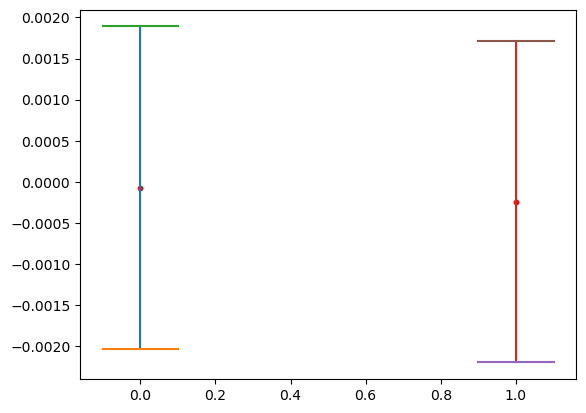

In [241]:
plt.plot([0,0], [mci1[1], mci1[2]])
plt.scatter([0], [mci1[0]], c='r', s=10)
plt.plot([-0.1, 0.1], [mci1[1], mci1[1]])
plt.plot([-0.1, 0.1], [mci1[2], mci1[2]])

plt.plot([1,1], [mci2[1], mci2[2]])
plt.scatter([1], [mci2[0]], c='r', s=10)
plt.plot([0.9, 1.1], [mci2[1], mci2[1]])
plt.plot([0.9, 1.1], [mci2[2], mci2[2]])
plt.show()

### 3.2 Стат-тесты

In [96]:
scipy.stats.ttest_ind(a1, a2)

Ttest_indResult(statistic=-0.1400423837741777, pvalue=0.8886265285603494)

# Доля (конверсия)

## 1. Необходимый объем выборки

In [99]:
conv_arr1 = scipy.stats.bernoulli.rvs(p=0.5, size=1000)

In [108]:
conv_arr1_mean = np.mean(conv_arr1)

In [109]:
conv_arr1_sampled_std = np.std(conv_arr1, ddof=1)

In [110]:
conv_arr1_sampled_std

0.49967356711524546

In [113]:
conv_eff_size = (0.6 - conv_arr1_mean) / conv_arr1_sampled_std

In [114]:
conv_eff_size

0.15209930042681485

In [115]:
zt_ind_solve_power(conv_eff_size, alpha=0.05, power=0.8)

678.5504977547301

## 2. АА-тест

In [116]:
conv_arr_aa_1 = scipy.stats.bernoulli.rvs(p=0.5, size=1000)

In [117]:
conv_arr_aa_2 = scipy.stats.bernoulli.rvs(p=0.5, size=1000)

In [119]:
conv_alphas = []
for _ in range(10000):
    conv_alphas.append(ztest(np.random.choice(a1, 100000), np.random.choice(a2, 100000))[1])

In [120]:
sum(np.array(conv_alphas) < 0.05) / len(conv_alphas)

0.0554

## 3. Выводы по успешности аб-теста

### 3.1 Доверительные интервалы

In [123]:
conv_arr_aa_1_ci = proportion_confint(sum(conv_arr_aa_1), len(conv_arr_aa_1))

In [124]:
conv_arr_aa_2_ci = proportion_confint(sum(conv_arr_aa_2), len(conv_arr_aa_2))

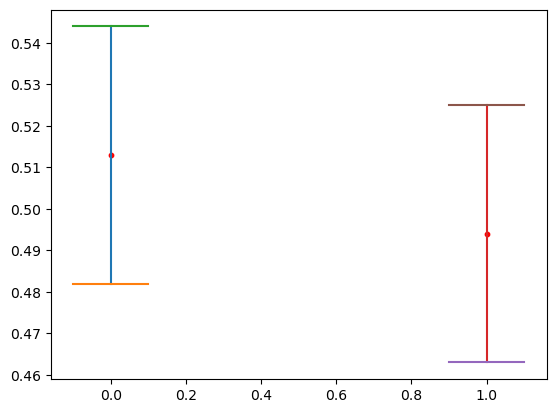

In [127]:
plt.plot([0,0], [conv_arr_aa_1_ci[0], conv_arr_aa_1_ci[1]])
plt.scatter([0], [conv_arr_aa_1.mean()], c='r', s=10)
plt.plot([-0.1, 0.1], [conv_arr_aa_1_ci[0], conv_arr_aa_1_ci[0]])
plt.plot([-0.1, 0.1], [conv_arr_aa_1_ci[1], conv_arr_aa_1_ci[1]])

plt.plot([1,1], [conv_arr_aa_2_ci[0], conv_arr_aa_2_ci[1]])
plt.scatter([1], [conv_arr_aa_2.mean()], c='r', s=10)
plt.plot([0.9, 1.1], [conv_arr_aa_2_ci[0], conv_arr_aa_2_ci[0]])
plt.plot([0.9, 1.1], [conv_arr_aa_2_ci[1], conv_arr_aa_2_ci[1]])
plt.show()

### 3.2 Стат-тесты

In [186]:
ztest(conv_arr_aa_1, conv_arr_aa_2)

(0.8494550284014832, 0.3956281441526125)

# Медиана

In [171]:
medians_a1 = []
for _ in range(1000):
    medians_a1.append(np.median(np.random.choice(a1, size = 1000)))

In [246]:
np.mean(medians_a1)

0.001558021465890249

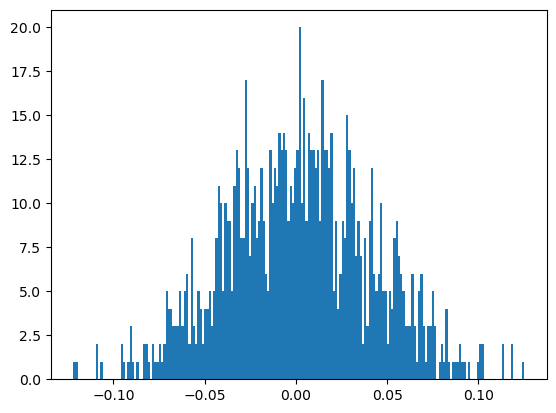

In [245]:
plt.hist(medians_a1, bins=200)
plt.show()

In [182]:
effect_size = (0.01 - np.mean(medians_a1)) / np.std(medians_a1, ddof=1)

In [183]:
effect_size

0.2104076343891827

In [220]:
TTestIndPower().solve_power(effect_size, alpha=0.05, power=0.8)

/Users/sergey.malyshev/anaconda3/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: invalid value encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/Users/sergey.malyshev/anaconda3/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: invalid value encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)
/Users/sergey.malyshev/anaconda3/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:6832: RuntimeWarning: overflow encountered in _nct_sf
  return np.clip(_boost._nct_sf(x, df, nc), 0, 1)
/Users/sergey.malyshev/anaconda3/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:6826: RuntimeWarning: overflow encountered in _nct_cdf
  return np.clip(_boost._nct_cdf(x, df, nc), 0, 1)


355.54241234412

In [172]:
medians_a1_ci = zconfint(medians_a1)

In [173]:
np.mean(medians_a1)

0.001558021465890249

In [174]:
medians_a2 = []
for _ in range(1000):
    medians_a2.append(np.median(np.random.choice(a2, size = 1000)))

In [175]:
medians_a2_ci = zconfint(medians_a2)

In [176]:
np.mean(medians_a2)

0.0010272485094024442

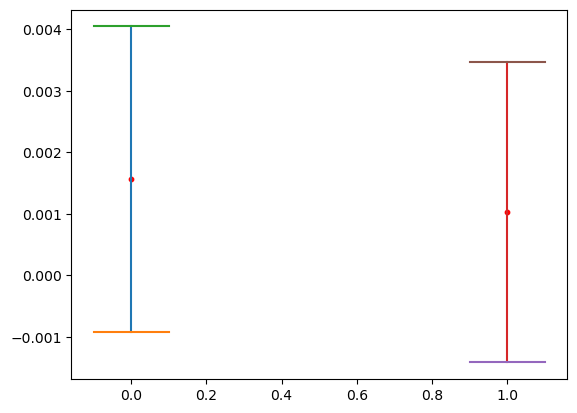

In [177]:
plt.plot([0,0], [medians_a1_ci[0], medians_a1_ci[1]])
plt.scatter([0], [np.mean(medians_a1)], c='r', s=10)
plt.plot([-0.1, 0.1], [medians_a1_ci[0], medians_a1_ci[0]])
plt.plot([-0.1, 0.1], [medians_a1_ci[1], medians_a1_ci[1]])

plt.plot([1,1], [medians_a2_ci[0], medians_a2_ci[1]])
plt.scatter([1], [np.mean(medians_a2)], c='r', s=10)
plt.plot([0.9, 1.1], [medians_a2_ci[0], medians_a2_ci[0]])
plt.plot([0.9, 1.1], [medians_a2_ci[1], medians_a2_ci[1]])
plt.show()

In [222]:
scipy.stats.ttest_ind(medians_a1, medians_a2)

Ttest_indResult(statistic=0.29830973449900045, pvalue=0.7654977939151152)